# Coverage-based Batch Bayesian Optimization

Selected points: [0.80267559 0.73578595 0.86956522 2.00668896 1.88628763 2.1270903
 1.76588629 3.19732441 2.24749164 0.64214047]


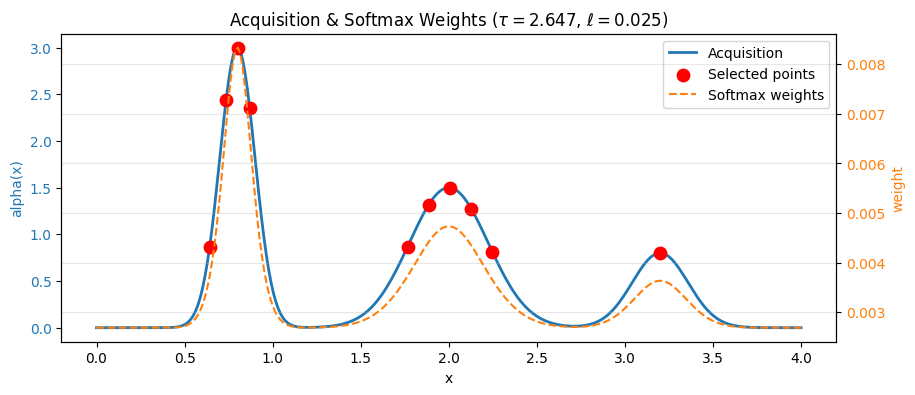

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax

# ===============================
# 1. 定义 acquisition function（连续，多峰）
# ===============================
def acquisition(x):
    """
    多峰 acquisition, 不同峰值高度
    """
    return (
        3.0 * np.exp(-(x - 0.8)**2 / 0.02) +
        1.5 * np.exp(-(x - 2.0)**2 / 0.10) +
        0.8 * np.exp(-(x - 3.2)**2 / 0.05)
    )

# ===============================
# 2. 定义 kernel（用于 coverage）
# ===============================
def rbf_kernel(x, y, lengthscale=0.25):
    return np.exp(-(x - y)**2 / (2 * lengthscale**2))

# ===============================
# 3. Coverage-based greedy batch selection
# ===============================
def coverage_batch_selection(C, alpha_c, q, tau, lengthscale=0.25):
    """
    C         : candidate points, shape (N,)
    alpha_c  : acquisition values on C
    q         : batch size
    tau       : softmax temperature
    """
    N = len(C)

    # Softmax normalization
    weights = softmax(alpha_c / tau)

    # Precompute kernel matrix
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            K[i, j] = rbf_kernel(C[i], C[j], lengthscale)

    S = []                  # selected indices
    m = np.zeros(N)         # current coverage per candidate

    for _ in range(q):
        best_gain = -np.inf
        best_idx = None

        for i in range(N):
            if i in S:
                continue

            # marginal coverage gain
            gain = np.sum(weights * (np.maximum(K[:, i], m) - m))

            if gain > best_gain:
                best_gain = gain
                best_idx = i

        # update
        S.append(best_idx)
        m = np.maximum(m, K[:, best_idx])

    return C[S], S, weights

# ===============================
# 4. 运行实验
# ===============================
if __name__ == "__main__":

    # 连续空间
    N = 300
    C = np.linspace(0, 4, N)
    alpha_c = acquisition(C)

    # batch size
    q = 10

    # temperature（关键）
    tau = 4 * np.std(alpha_c)
    lengthscale = 0.025

    selected_x, selected_idx, weights = coverage_batch_selection(
        C, alpha_c, q, tau, lengthscale
    )

    print("Selected points:", selected_x)

    # ===============================
    # 5. 可视化
    # ===============================
fig, ax1 = plt.subplots(figsize=(10, 4))

# 左轴：acquisition
ax1.plot(C, alpha_c, label="Acquisition", linewidth=2, color='C0')
ax1.scatter(selected_x,
            acquisition(selected_x),
            color="red",
            s=80,
            zorder=5,
            label="Selected points")
ax1.set_xlabel("x")
ax1.set_ylabel("alpha(x)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# 右轴：softmax weights
ax2 = ax1.twinx()
ax2.plot(C, weights, label="Softmax weights",
         linestyle='--', color='C1')
ax2.set_ylabel("weight", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

# 合并 legend（关键）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(rf"Acquisition & Softmax Weights ($\tau={tau:.3f}$, $\ell={lengthscale:.3f}$)")
plt.grid(alpha=0.3)
plt.show()
